In [1]:
data <- read.csv("IBM.csv")

In [2]:
head(data)

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
2,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
3,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
4,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
5,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
6,32,No,Research & Development,2,2,Life Sciences,4,4,Single,3068,0,2,7


In [3]:
dim(data)

[1] 1470   13

In [4]:
names(data)

[1] "Age"                     "Attrition"              
 [3] "Department"              "DistanceFromHome"       
 [5] "Education"               "EducationField"         
 [7] "EnvironmentSatisfaction" "JobSatisfaction"        
 [9] "MaritalStatus"           "MonthlyIncome"          
[11] "NumCompaniesWorked"      "WorkLifeBalance"        
[13] "YearsAtCompany"

In [5]:
summary(data)

      Age            Attrition        Department   DistanceFromHome
 Min.   :18.00   Length   :1470   Length   :1470   Min.   : 1.000  
 1st Qu.:30.00   N.unique :   2   N.unique :   3   1st Qu.: 2.000  
 Median :36.00   N.blank  :   0   N.blank  :   0   Median : 7.000  
 Mean   :36.92   Min.nchar:   2   Min.nchar:   5   Mean   : 9.193  
 3rd Qu.:43.00   Max.nchar:   3   Max.nchar:  22   3rd Qu.:14.000  
 Max.   :60.00                                     Max.   :29.000  
   Education       EducationField EnvironmentSatisfaction JobSatisfaction
 Min.   :1.000   Length   :1470   Min.   :1.000           Min.   :1.000  
 1st Qu.:2.000   N.unique :   6   1st Qu.:2.000           1st Qu.:2.000  
 Median :3.000   N.blank  :   0   Median :3.000           Median :3.000  
 Mean   :2.913   Min.nchar:   5   Mean   :2.722           Mean   :2.729  
 3rd Qu.:4.000   Max.nchar:  16   3rd Qu.:4.000           3rd Qu.:4.000  
 Max.   :5.000                    Max.   :4.000           Max.   :4.000  
   Mar

In [6]:
colSums(is.na(data))

Age               Attrition              Department 
                      0                       0                       0 
       DistanceFromHome               Education          EducationField 
                      0                       0                       0 
EnvironmentSatisfaction         JobSatisfaction           MaritalStatus 
                      0                       0                       0 
          MonthlyIncome      NumCompaniesWorked         WorkLifeBalance 
                      0                       0                       0 
         YearsAtCompany 
                      0

In [8]:
data$Age[is.na(data$Age)] <- mean(data$Age, na.rm = TRUE)
data$MonthlyIncome[is.na(data$MonthlyIncome)] <- mean(data$MonthlyIncome, na.rm = TRUE)


In [9]:
data$DistanceFromHome[is.na(data$DistanceFromHome)] <- median(data$DistanceFromHome, na.rm = TRUE)

In [10]:
mode_attrition <- names(sort(table(data$Attrition), decreasing = TRUE))[1]
data$Attrition[is.na(data$Attrition)] <- mode_attrition


In [12]:
install.packages("ggplot2")
install.packages("corrplot")

Installing package into 'C:/Users/MISBA T/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)

also installing the dependencies 'cpp11', 'farver', 'labeling', 'R6', 'RColorBrewer', 'viridisLite', 'gtable', 'isoband', 'S7', 'scales', 'withr'




package 'cpp11' successfully unpacked and MD5 sums checked
package 'farver' successfully unpacked and MD5 sums checked
package 'labeling' successfully unpacked and MD5 sums checked
package 'R6' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked
package 'viridisLite' successfully unpacked and MD5 sums checked
package 'gtable' successfully unpacked and MD5 sums checked
package 'isoband' successfully unpacked and MD5 sums checked
package 'S7' successfully unpacked and MD5 sums checked
package 'scales' successfully unpacked and MD5 sums checked
package 'withr' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\MISBA T\AppData\Local\Temp\RtmpekHxF0\downloaded_packages


Installing package into 'C:/Users/MISBA T/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'corrplot' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\MISBA T\AppData\Local\Temp\RtmpekHxF0\downloaded_packages


In [13]:
library(ggplot2)
library(corrplot)

corrplot 0.95 loaded



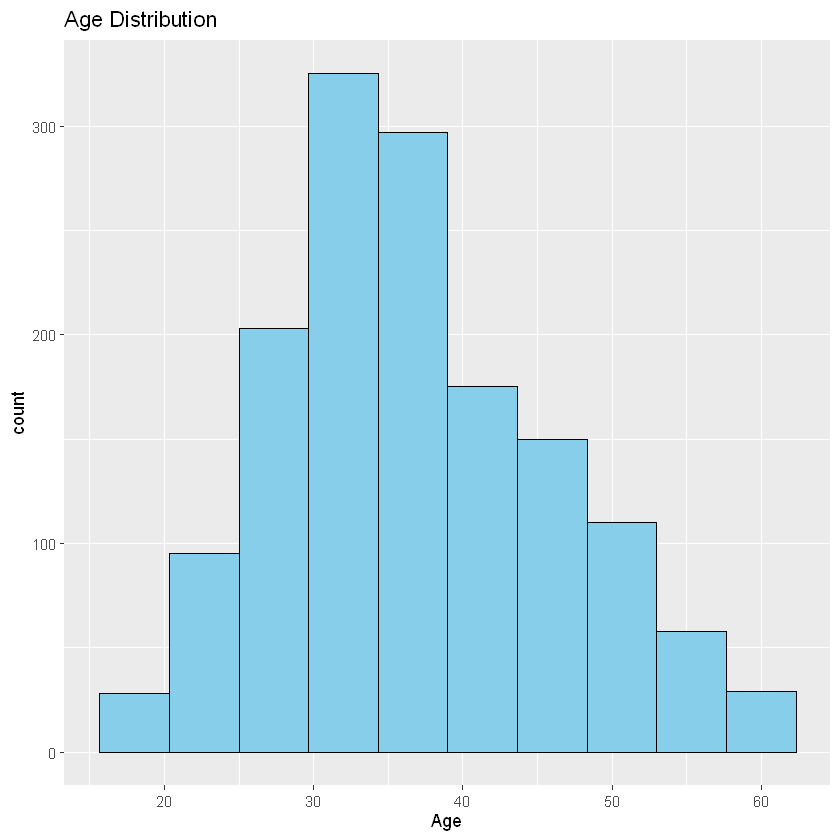

In [14]:
ggplot(data, aes(x = Age)) +
  geom_histogram(fill = "skyblue", color = "black", bins = 10) +
  ggtitle("Age Distribution")

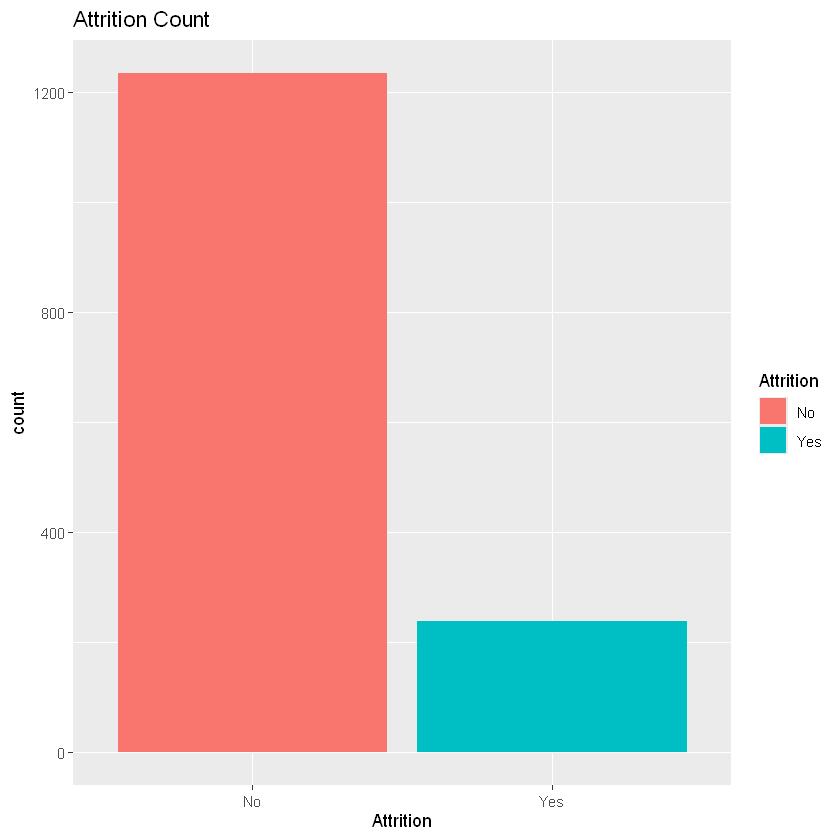

In [15]:
ggplot(data, aes(x = Attrition, fill = Attrition)) +
  geom_bar() +
  ggtitle("Attrition Count")

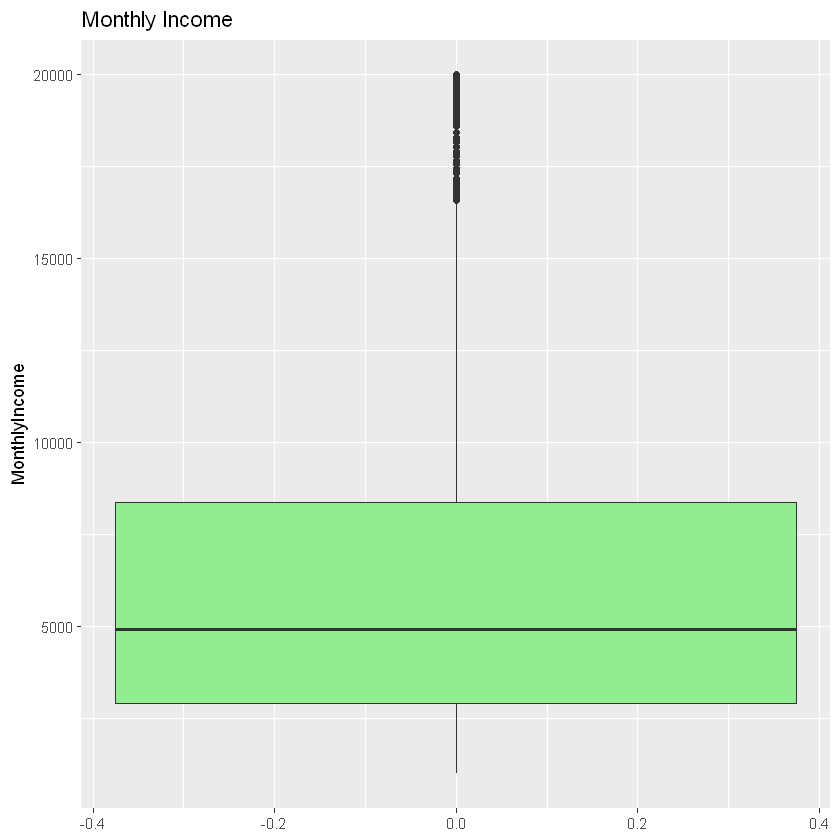

In [16]:
ggplot(data, aes(y = MonthlyIncome)) +
  geom_boxplot(fill = "lightgreen") +
  ggtitle("Monthly Income")

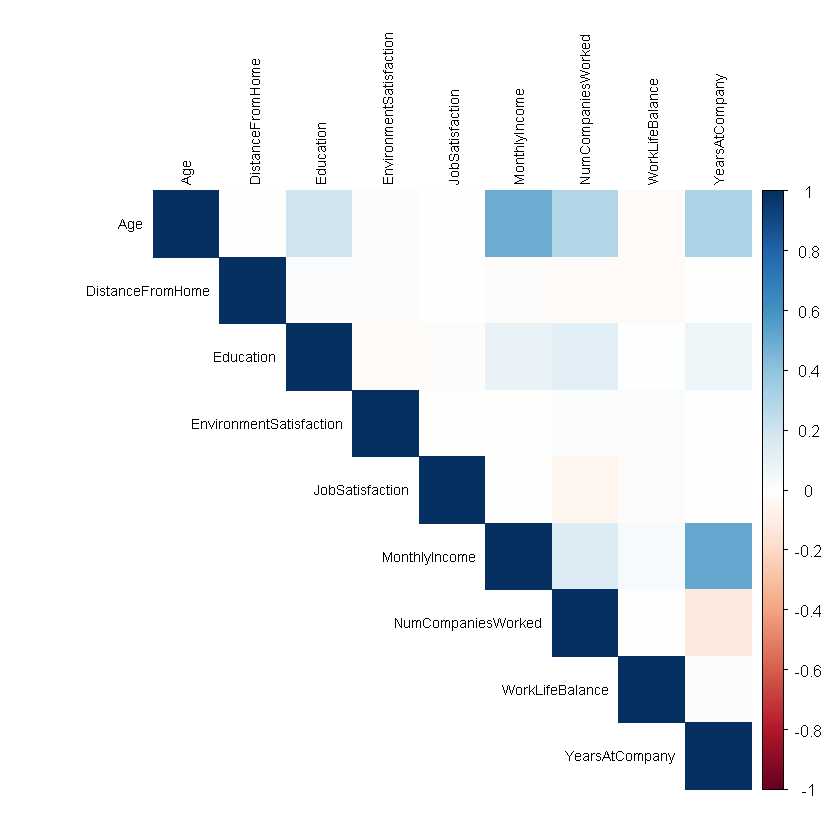

In [17]:
num_data <- data[sapply(data, is.numeric)]
cor_matrix <- cor(num_data)

corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.col = "black",
         tl.cex = 0.7)